# Customer Churn Prediction using Machine Learning

## Project Overview
Customer churn is one of the most important business problems in industries such as telecom, banking, insurance, and subscription services. This project predicts whether a customer is likely to churn using machine learning classification algorithms.

The workflow includes:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation
- Model Comparison

## 1. **Import Libraries**

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier

C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 2. **Check Data**

In [3]:
churn = pd.read_csv('churn.csv')

In [4]:
churn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print(churn.shape)

(7043, 21)


In [6]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Note :**

In this data "churn" will be considered as target and remaining columns apart from "customer_id" will be considered as 
features to predict that customer will renew the policy or not. That means it is a supervided classifictaion 
problem and it can be solved by decision tree or any linear based model like logistic regression model...

In [7]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [8]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
churn.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [10]:

churn.TotalCharges = pd.to_numeric(churn.TotalCharges, errors = 'coerce')

## 3. **EDA**

In [11]:
churn.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
from sklearn.impute import SimpleImputer

In [13]:
churn['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

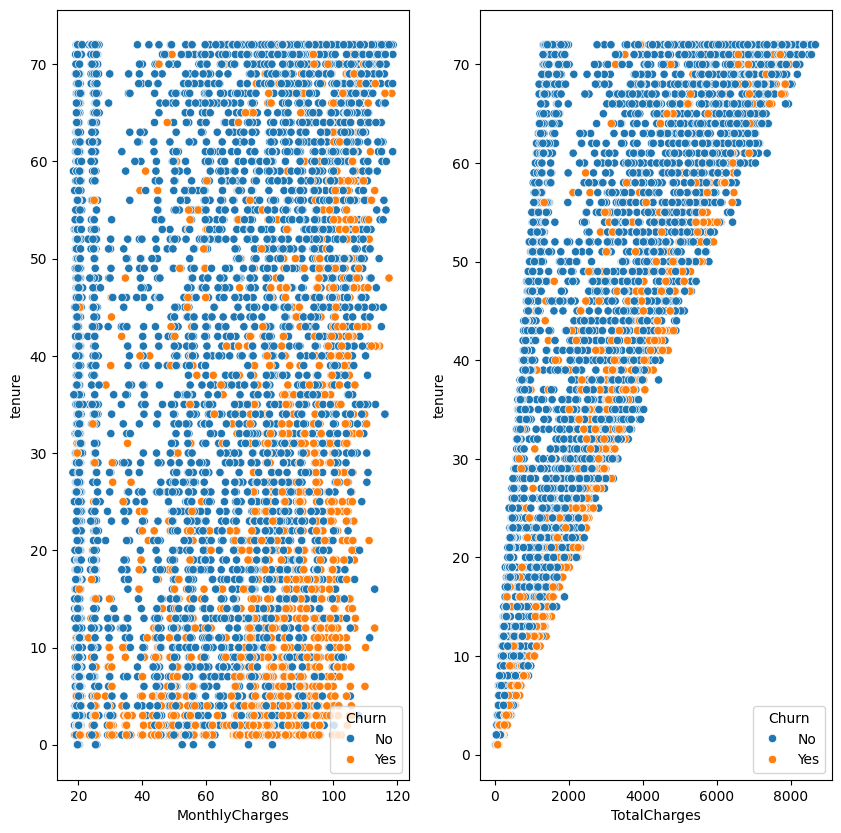

In [15]:
## what other the various inference we can draw :

fig , ax = plt.subplots(1,2,figsize =(10,10))
sns.scatterplot(x = "MonthlyCharges", y ="tenure", hue = "Churn", data = churn, ax = ax[0])
sns.scatterplot(x = "TotalCharges", y ="tenure", hue = "Churn", data = churn, ax = ax[1]);

In [16]:
## let assume churn no means they will renew:
## churn yes means they will not renew :

<Axes: xlabel='gender', ylabel='count'>

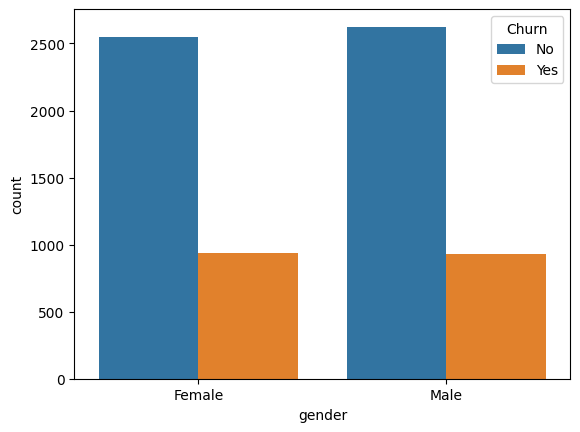

In [17]:
## gender, SeniorCitizen,Partner,Dependents

sns.countplot(x = 'gender',hue = 'Churn',data = churn)

<Axes: xlabel='SeniorCitizen', ylabel='count'>

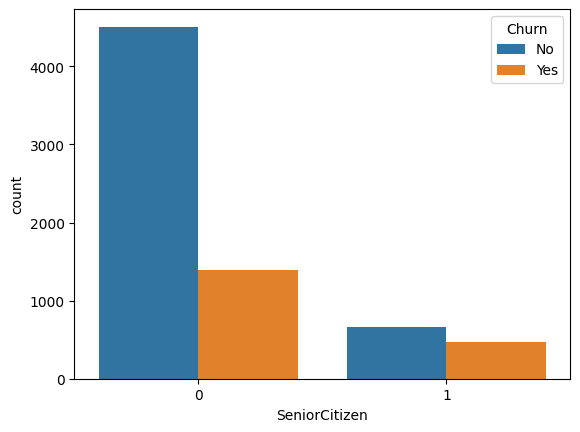

In [18]:
sns.countplot(x = 'SeniorCitizen',hue = 'Churn',data = churn)

<Axes: xlabel='Partner', ylabel='count'>

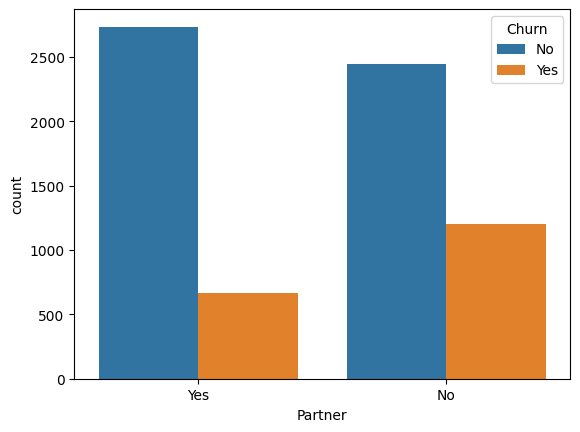

In [19]:
sns.countplot(x = 'Partner',hue = 'Churn',data = churn)

In [20]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [36]:
## i will divide my whole data into categorical and numeric features:
## then i will do label encoding on categrical features:
## i will concat both the dataset to achieve my main data which i will use for Model building:


num = churn.select_dtypes(include = np.number)
obj = churn.select_dtypes(include='object')


from sklearn.preprocessing import LabelEncoder

# Encode target only
le = LabelEncoder()
churn["Churn"] = le.fit_transform(churn["Churn"])

# One Hot Encoding for input features
churndf = pd.get_dummies(
    churn,
    columns=[
        "gender",
        "Partner",
        "Dependents",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod"
    ],
    drop_first=True
)

C:\Users\Asus\AppData\Local\Temp\ipykernel_21276\1316741610.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj = churn.select_dtypes(include='object')


In [22]:
churndf = pd.concat([num,obj2],axis =1)
print(churn.shape)
churndf.head(2)
print(churndf.shape)

(7043, 20)
(7043, 20)


## **4. Model Preparation**

In [37]:
x = churndf.drop(
['Churn','TotalCharges'],
axis=1
)

y = churndf["Churn"]

In [38]:
x

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,True,True,True,True,False,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,False,True,True,True,False,True,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,False,True,True,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,True,True,False,True,False,True,True,...,False,False,False,False,False,False,True,False,False,True


In [39]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int32

* **Train Test Split**

In [40]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [83]:
Le = LogisticRegression(max_iter=1000)
Le.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [104]:
x_train = pd.DataFrame(x_train, columns=x.columns)
x_test = pd.DataFrame(x_test, columns=x.columns)

## 5. **Model Evaluation**

* **Logistic Regression Model**  

---



In [105]:
from sklearn.linear_model import LogisticRegression
Le = LogisticRegression()

In [106]:
Le.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [107]:
Le.score(x_train, y_train)

0.8052893148739794

In [108]:
predictions = Le.predict(x_test)

In [109]:
Le.score(x_test, y_test)

0.7977288857345636

In [110]:
classification_report(predictions, y_test)

'              precision    recall  f1-score   support\n\n           0       0.89      0.85      0.87      1086\n           1       0.55      0.64      0.59       323\n\n    accuracy                           0.80      1409\n   macro avg       0.72      0.74      0.73      1409\nweighted avg       0.81      0.80      0.80      1409\n'

In [111]:
#plot_roc_curve(Le, x_test, y_test)

* **Decision Tree Classifier**

---



In [112]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()

treemodel = tree.fit(x_train,y_train)
treemodel.score(x_train,y_train)

0.9978700745473909

In [113]:
## validate the model on test dataset:
testmodel =  treemodel.score(x_test,y_test)
print(testmodel)


0.7295954577714692


In [114]:
## how to generate confusion matrix on test dataset:

test_predict =treemodel.predict(x_test)
classification_report(y_test,test_predict)

'              precision    recall  f1-score   support\n\n           0       0.82      0.81      0.81      1035\n           1       0.49      0.51      0.50       374\n\n    accuracy                           0.73      1409\n   macro avg       0.66      0.66      0.66      1409\nweighted avg       0.73      0.73      0.73      1409\n'

In [115]:
# plot_roc_curve(treemodel,x_test,y_test)

In [116]:
## AUC is 0.67 that means model has not predicted well in my test dataset

In [117]:
## we will compare this model with logistic regresion:

* **Plotting Tree**

[Text(0.5, 0.875, 'x[1] <= -0.651\ngini = 0.39\nsamples = 5634\nvalue = [4139, 1495]'),
 Text(0.25, 0.625, 'x[9] <= 0.119\ngini = 0.495\nsamples = 2042\nvalue = [1120, 922]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[1] <= -1.18\ngini = 0.403\nsamples = 1174\nvalue = [845.0, 329.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'x[1] <= -1.261\ngini = 0.433\nsamples = 868\nvalue = [275, 593]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'x[9] <= 0.119\ngini = 0.268\nsamples = 3592\nvalue = [3019, 573]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[24] <= 0.605\ngini = 0.115\nsamples = 1977\nvalue = [1856, 121]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'x[1] <= 0.937\ngini = 0.403\nsamples = 1615\nvalue = [1163.0, 452.0]'),
 Text(0.8125, 0.125, '\n  (...)  \n'),
 Text(0.9375, 0.125, '\n  (...)  \n')]

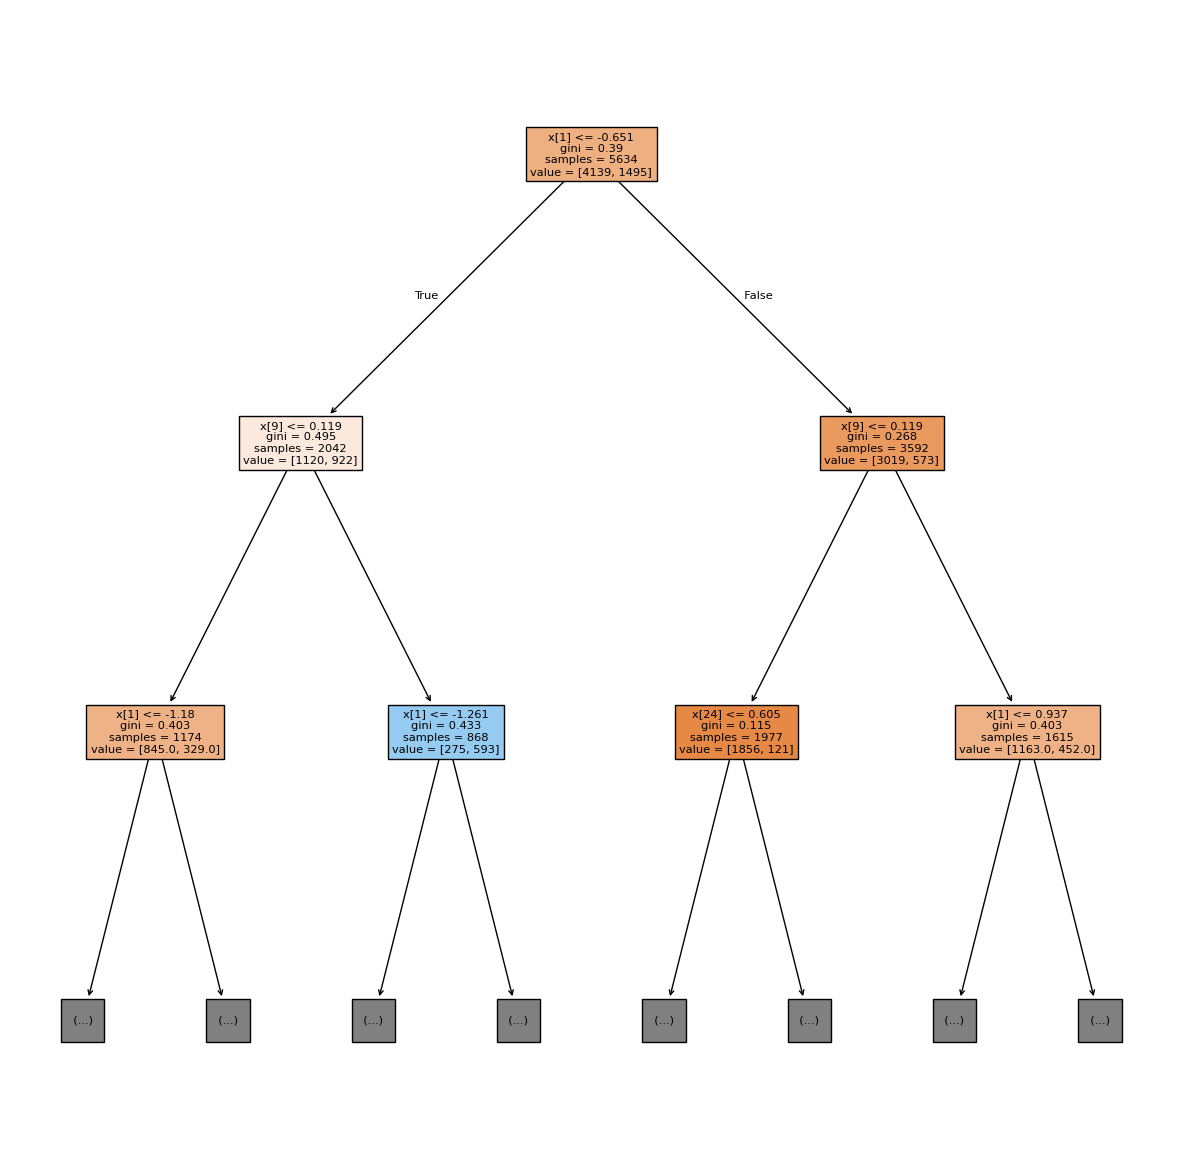

In [118]:
## how to check the tree:
from sklearn.tree import plot_tree
plt.figure(figsize = (15,15))
plot_tree(treemodel,max_depth =2,filled = True)

* **Random Forest Classifier**

Training Accuracy : 0.9978700745473909
Testing Accuracy  : 0.7856635911994322

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



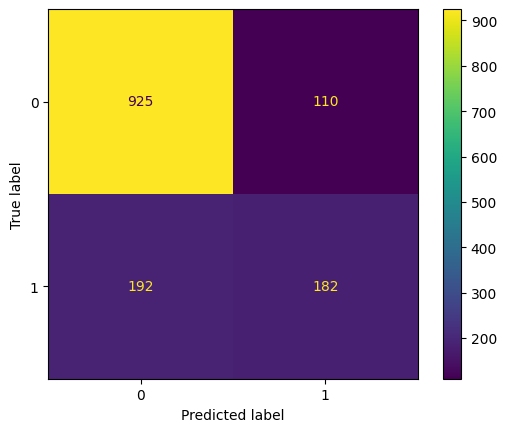

In [119]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

print("Training Accuracy :", rf.score(x_train, y_train))
print("Testing Accuracy  :", rf.score(x_test, y_test))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_estimator(rf, x_test, y_test)

*  **Model Comparison**

In [120]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        Le.score(x_test, y_test),
        treemodel.score(x_test, y_test),
        rf.score(x_test, y_test)
    ]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy
0,Logistic Regression,0.797729
2,Random Forest,0.785664
1,Decision Tree,0.729595


In [121]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression Predictions
lr_pred = Le.predict(x_test)
lr_prob = Le.predict_proba(x_test)[:,1]

# Decision Tree Predictions
dt_pred = treemodel.predict(x_test)
dt_prob = treemodel.predict_proba(x_test)[:,1]

# Random Forest Predictions
rf_pred = rf.predict(x_test)
rf_prob = rf.predict_proba(x_test)[:,1]

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,dt_pred),
        f1_score(y_test,rf_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test,lr_prob),
        roc_auc_score(y_test,dt_prob),
        roc_auc_score(y_test,rf_prob)
    ]

})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.798,0.638,0.551,0.591,0.839
1,Decision Tree,0.730,0.491,0.513,0.502,0.661
2,Random Forest,0.786,0.623,0.487,0.547,0.820


In [122]:
from sklearn.metrics import roc_auc_score

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, Le.predict_proba(x_test)[:,1]))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf.predict_proba(x_test)[:,1]))

Logistic Regression ROC-AUC: 0.8388333462502261
Random Forest ROC-AUC: 0.8201581027667983


In [123]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.239126
2,MonthlyCharges,0.225020
9,InternetService_Fiber optic,0.043885
24,Contract_Two year,0.040100
27,PaymentMethod_Electronic check,0.040052
3,gender_Male,0.033538
18,TechSupport_Yes,0.029762
23,Contract_One year,0.029211
25,PaperlessBilling_Yes,0.028990
4,Partner_Yes,0.027978


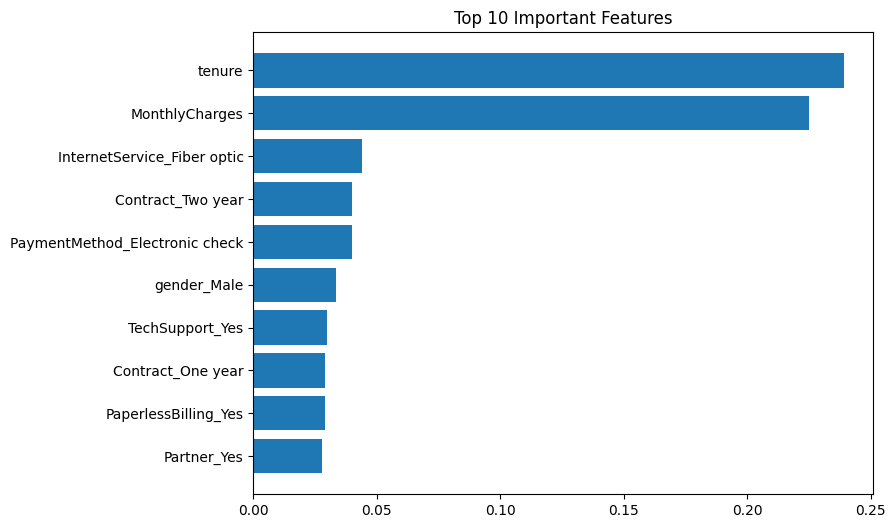

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(feature_importance["Feature"][:10],
         feature_importance["Importance"][:10])

plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [125]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train,y_train)

print("Best Parameters :",grid.best_params_)
print("Best CV Score :",grid.best_score_)

Best Parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score : 0.8031571266239139


In [126]:
best_rf = grid.best_estimator_

pred = best_rf.predict(x_test)

print("Test Accuracy :",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Test Accuracy : 0.8026969481902059
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



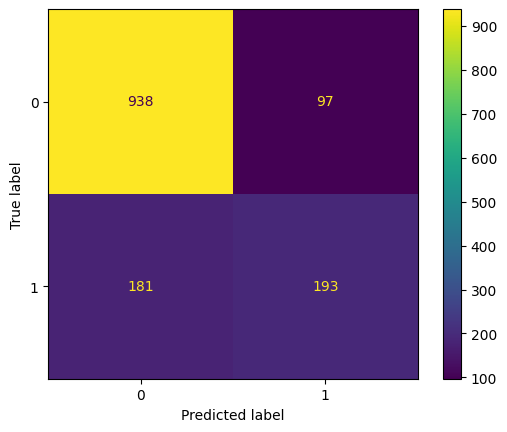

In [127]:
ConfusionMatrixDisplay.from_estimator(best_rf,x_test,y_test)

* **Exporting Tree Code**

In [128]:
from sklearn.tree import export_text
r = export_text(treemodel, feature_names=(list(x_train.columns)))
print(r)

|--- tenure <= -0.65
|   |--- InternetService_Fiber optic <= 0.12
|   |   |--- tenure <= -1.18
|   |   |   |--- StreamingMovies_No internet service <= 0.69
|   |   |   |   |--- MonthlyCharges <= -0.16
|   |   |   |   |   |--- PaperlessBilling_Yes <= -0.19
|   |   |   |   |   |   |--- StreamingTV_Yes <= 0.23
|   |   |   |   |   |   |   |--- SeniorCitizen <= 0.91
|   |   |   |   |   |   |   |   |--- gender_Male <= -0.01
|   |   |   |   |   |   |   |   |   |--- PaymentMethod_Credit card (automatic) <= 0.69
|   |   |   |   |   |   |   |   |   |   |--- MonthlyCharges <= -0.33
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |   |   |   |   |   |   |--- MonthlyCharges >  -0.33
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- PaymentMethod_Credit card (automatic) >  0.69
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- gender_Male >  -0.01
|   |   |   |   |  